# Previsão de Rotatividade de Funcionários (Turnover)

Este notebook contém o fluxo completo de Machine Learning para a previsão de rotatividade (turnover) de funcionários, alinhado com as especificações do **Trabalho Machine Learning C3**.

**Integrantes do Grupo:** Gabriel Freitas Souza, Indyanny Rodrigues Peixinho

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Gabriel-Freitas-S/previsao-turnover-funcionarios/blob/main/notebooks/previsao_turnover.ipynb)

In [1]:
# Instalação silenciosa de dependências caso esteja no Google Colab
import sys
import subprocess

def install_packages():
    try:
        import google.colab
        print("Ambiente Google Colab detectado. Instalando dependências...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "joblib", "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"], check=True)
        print("Dependências instaladas com sucesso!")
    except ImportError:
        print("Ambiente Local detectado. Certifique-se de que o seu virtualenv está ativo com as dependências instaladas.")

install_packages()

Ambiente Local detectado. Certifique-se de que o seu virtualenv está ativo com as dependências instaladas.


In [2]:
# Detecção de ambiente
IS_COLAB = False
try:
    import google.colab
    IS_COLAB = True
    print("Executando no Google Colab.")
except ImportError:
    print("Executando localmente.")

Executando localmente.


In [3]:
# Download dinâmico do dataset caso esteja no Colab
import os
import urllib.request

DATA_DIR = "data"
DATA_FILE = "HR_Employee_Attrition.csv"
DATA_PATH = os.path.join(DATA_DIR, DATA_FILE)

if IS_COLAB:
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)
    if not os.path.exists(DATA_PATH):
        url = "https://raw.githubusercontent.com/Gabriel-Freitas-S/previsao-turnover-funcionarios/main/data/HR_Employee_Attrition.csv"
        print(f"Baixando dataset de: {url}")
        urllib.request.urlretrieve(url, DATA_PATH)
        print("Download concluído!")
else:
    # Se executando localmente, assumimos que o arquivo está no diretório correto relativo à raiz
    if not os.path.exists(DATA_PATH) and os.path.exists(os.path.join("..", DATA_PATH)):
        DATA_PATH = os.path.join("..", DATA_PATH)
    print(f"Caminho do dataset local configurado para: {DATA_PATH}")

Caminho do dataset local configurado para: ../data/HR_Employee_Attrition.csv


## 1. Definição do Problema

A rotatividade de funcionários (*Turnover*) representa um desafio crítico para as organizações. A perda inesperada de talentos, em especial em posições que gerenciam fluxos documentais vitais ou operam em setores técnicos de alta complexidade (como a área de saúde e RH), acarreta altos custos financeiros (recrutamento, integração, rescisão) e perda de produtividade.

**Objetivo:** Construir um classificador de aprendizado de máquina capaz de prever se um funcionário tem alta propensão a deixar a empresa (variável `Turnover`).
- **Tipo de Problema:** Classificação Binária (Turnover = 1 (Sim) / 0 (Não))
- **Métrica de Foco:** F1-Score (devido ao forte desbalanceamento das classes: ~84% de não-turnover e ~16% de turnover).

## 2. Importação de Bibliotecas

Importação das bibliotecas essenciais para manipulação de dados, modelagem preditiva, otimização e visualização.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
sns.set_style('whitegrid')

## 3. Carregamento e Exploração Inicial com Tradução

Carregamos o dataset *IBM HR Analytics* e traduzimos todas as colunas e categorias textuais para o português.

In [5]:
COLUMNS_MAP = {
    'Age': 'Idade',
    'Attrition': 'Turnover',
    'BusinessTravel': 'ViagemNegocios',
    'DailyRate': 'ValorDiaria',
    'Department': 'Departamento',
    'DistanceFromHome': 'DistanciaTrabalho',
    'Education': 'Escolaridade',
    'EducationField': 'AreaFormacao',
    'EmployeeCount': 'ContagemFuncionarios',
    'EmployeeNumber': 'NumeroFuncionario',
    'EnvironmentSatisfaction': 'SatisfacaoAmbiente',
    'Gender': 'Genero',
    'HourlyRate': 'ValorHora',
    'JobInvolvement': 'EnvolvimentoTrabalho',
    'JobLevel': 'NivelCargo',
    'JobRole': 'Cargo',
    'JobSatisfaction': 'SatisfacaoCargo',
    'MaritalStatus': 'EstadoCivil',
    'MonthlyIncome': 'RendaMensal',
    'MonthlyRate': 'ValorMensal',
    'NumCompaniesWorked': 'NumeroEmpresasTrabalhou',
    'Over18': 'MaiorDe18',
    'OverTime': 'HoraExtra',
    'PercentSalaryHike': 'PercentualAumentoSalario',
    'PerformanceRating': 'AvaliacaoDesempenho',
    'RelationshipSatisfaction': 'SatisfacaoRelacionamento',
    'StandardHours': 'HorasPadrao',
    'StockOptionLevel': 'NivelOpcaoAcoes',
    'TotalWorkingYears': 'TotalAnosTrabalhados',
    'TrainingTimesLastYear': 'QtdTreinamentosAnoPassado',
    'WorkLifeBalance': 'EquilibrioVidaTrabalho',
    'YearsAtCompany': 'AnosEmpresa',
    'YearsInCurrentRole': 'AnosCargoAtual',
    'YearsSinceLastPromotion': 'AnosDesdeUltimaPromocao',
    'YearsWithCurrManager': 'AnosGerenteAtual'
}

def translate_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    categorical_translation = {
        'Attrition': {'Yes': 'Sim', 'No': 'Não'},
        'OverTime': {'Yes': 'Sim', 'No': 'Não'},
        'BusinessTravel': {
            'Travel_Rarely': 'Rara',
            'Travel_Frequently': 'Frequente',
            'Non-Travel': 'Não Viaja'
        },
        'Gender': {'Male': 'Masculino', 'Female': 'Feminino'},
        'MaritalStatus': {
            'Single': 'Solteiro',
            'Married': 'Casado',
            'Divorced': 'Divorciado'
        },
        'Department': {
            'Sales': 'Vendas',
            'Research & Development': 'Pesquisa & Desenvolvimento',
            'Human Resources': 'Recursos Humanos'
        },
        'JobRole': {
            'Sales Executive': 'Executivo de Vendas',
            'Research Scientist': 'Cientista de Pesquisa',
            'Laboratory Technician': 'Técnico de Laboratório',
            'Manufacturing Director': 'Diretor de Manufatura',
            'Healthcare Representative': 'Representante de Saúde',
            'Manager': 'Gerente',
            'Sales Representative': 'Representante de Vendas',
            'Research Director': 'Diretor de Pesquisa',
            'Human Resources': 'Recursos Humanos'
        },
        'EducationField': {
            'Life Sciences': 'Ciências da Vida',
            'Medical': 'Medicina',
            'Marketing': 'Marketing',
            'Technical Degree': 'Curso Técnico',
            'Other': 'Outro',
            'Human Resources': 'Recursos Humanos'
        }
    }
    for col, mapping in categorical_translation.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(df[col])
    df = df.rename(columns=COLUMNS_MAP)
    return df

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df = translate_dataframe(df)
print(f"Tamanho do Dataset: {df.shape[0]} linhas, {df.shape[1]} colunas.")

Tamanho do Dataset: 1470 linhas, 35 colunas.


In [6]:
# Exibição das primeiras linhas, tipos e distribuição da variável alvo em Português
display(df.head())
print("\n--- Informações do DataFrame ---")
df.info()
print("\n--- Distribuição da Variável Alvo (Turnover) ---")
print(df['Turnover'].value_counts())
print(df['Turnover'].value_counts(normalize=True).mul(100).round(2))

,Idade,Turnover,ViagemNegocios,ValorDiaria,Departamento,DistanciaTrabalho,Escolaridade,AreaFormacao,ContagemFuncionarios,NumeroFuncionario,...,SatisfacaoRelacionamento,HorasPadrao,NivelOpcaoAcoes,TotalAnosTrabalhados,QtdTreinamentosAnoPassado,EquilibrioVidaTrabalho,AnosEmpresa,AnosCargoAtual,AnosDesdeUltimaPromocao,AnosGerenteAtual
0,41,Sim,Rara,1102,Vendas,1,2,Ciências da Vida,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,Não,Frequente,279,Pesquisa & Desenvolvimento,8,1,Ciências da Vida,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Sim,Rara,1373,Pesquisa & Desenvolvimento,2,2,Outro,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,Não,Frequente,1392,Pesquisa & Desenvolvimento,3,4,Ciências da Vida,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,Não,Rara,591,Pesquisa & Desenvolvimento,2,1,Medicina,1,7,...,4,80,1,6,3,3,2,2,2,2



--- Informações do DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Idade                      1470 non-null   int64
 1   Turnover                   1470 non-null   str  
 2   ViagemNegocios             1470 non-null   str  
 3   ValorDiaria                1470 non-null   int64
 4   Departamento               1470 non-null   str  
 5   DistanciaTrabalho          1470 non-null   int64
 6   Escolaridade               1470 non-null   int64
 7   AreaFormacao               1470 non-null   str  
 8   ContagemFuncionarios       1470 non-null   int64
 9   NumeroFuncionario          1470 non-null   int64
 10  SatisfacaoAmbiente         1470 non-null   int64
 11  Genero                     1470 non-null   str  
 12  ValorHora                  1470 non-null   int64
 13  EnvolvimentoTrabalho       1470 non-null   int64
 14  N

## 4. Análise Exploratória de Dados (EDA) em Português

Investigando visualmente as correlações e os comportamentos dos atributos com relação ao desligamento voluntário (Turnover).

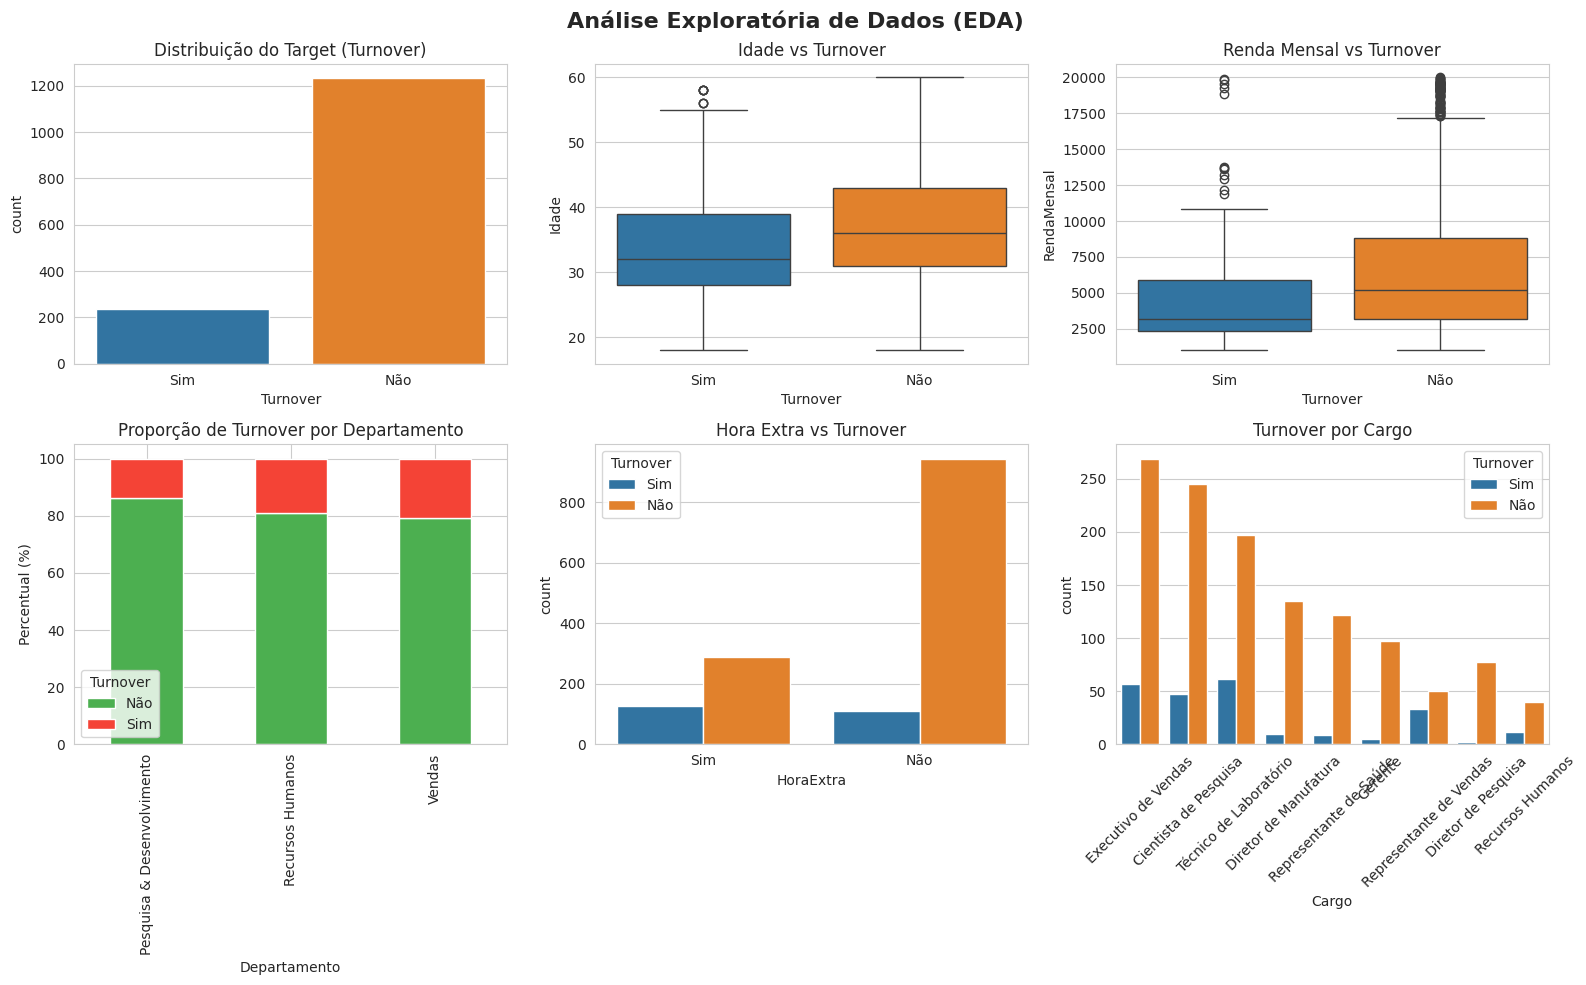

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Análise Exploratória de Dados (EDA)", fontsize=16, fontweight='bold')

# 1. Distribuição de Turnover
sns.countplot(data=df, x='Turnover', hue='Turnover', ax=axes[0, 0], legend=False)
axes[0, 0].set_title("Distribuição do Target (Turnover)")

# 2. Idade vs Turnover
sns.boxplot(data=df, x='Turnover', y='Idade', hue='Turnover', ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Idade vs Turnover")

# 3. Renda Mensal vs Turnover
sns.boxplot(data=df, x='Turnover', y='RendaMensal', hue='Turnover', ax=axes[0, 2], legend=False)
axes[0, 2].set_title("Renda Mensal vs Turnover")

# 4. Departamento vs Turnover (%)
dept_att = df.groupby('Departamento')['Turnover'].value_counts(normalize=True).unstack() * 100
dept_att.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#4CAF50', '#F44336'])
axes[1, 0].set_title("Proporção de Turnover por Departamento")
axes[1, 0].set_ylabel("Percentual (%)")
axes[1, 0].legend(title='Turnover')

# 5. Hora Extra vs Turnover
sns.countplot(data=df, x='HoraExtra', hue='Turnover', ax=axes[1, 1])
axes[1, 1].set_title("Hora Extra vs Turnover")

# 6. Cargo vs Turnover
sns.countplot(data=df, x='Cargo', hue='Turnover', ax=axes[1, 2])
axes[1, 2].set_title("Turnover por Cargo")
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

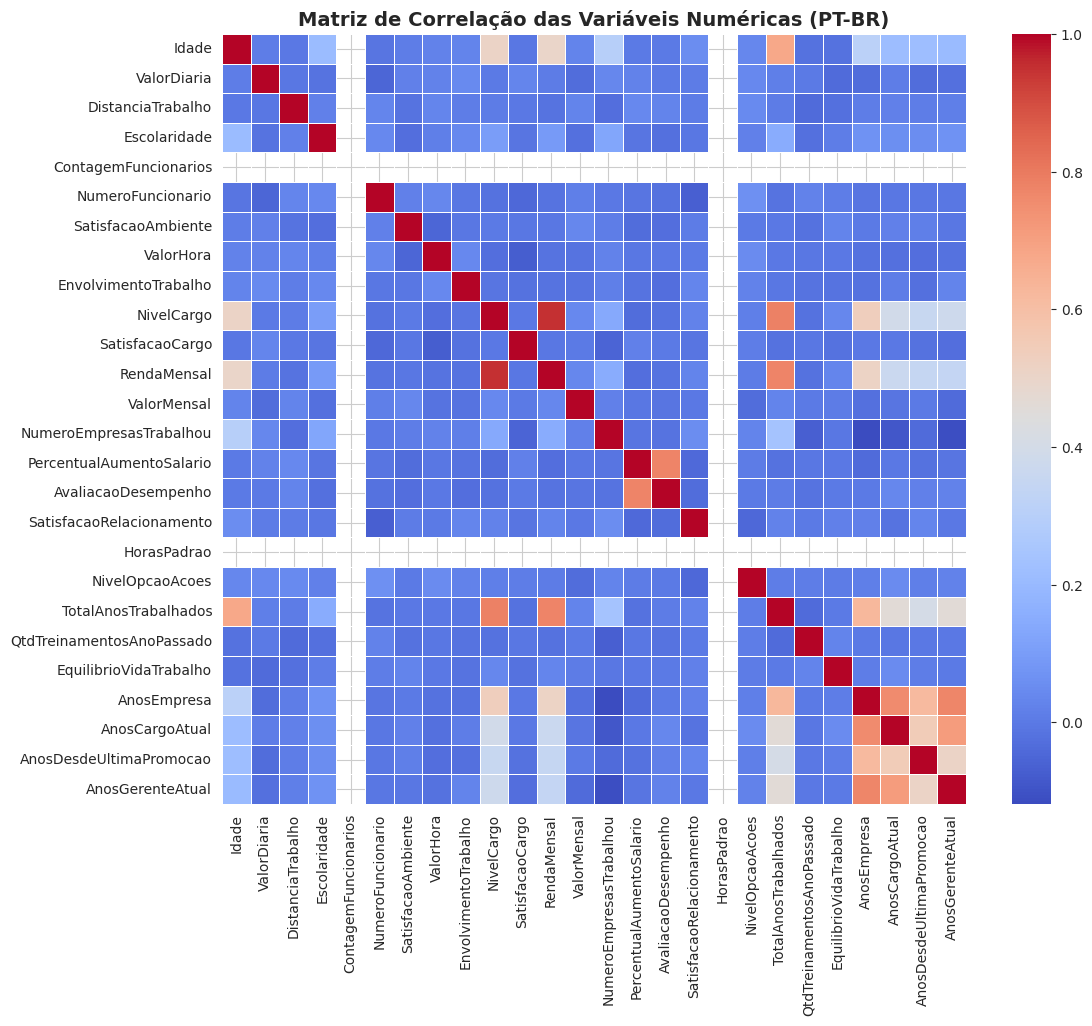

In [8]:
# Matriz de correlação para features numéricas em português
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlação das Variáveis Numéricas (PT-BR)", fontsize=14, fontweight='bold')
plt.show()

### Insights obtidos na EDA:
1. **Desbalanceamento:** Cerca de 83.88% permanecem (Não) e apenas 16.12% saem (Sim).
2. **Idade:** Funcionários mais jovens apresentam uma taxa de evasão superior.
3. **Renda Mensal:** Salários mais baixos possuem forte correlação com turnover (maior frequência de Sim no boxplot inferior).
4. **Hora Extra:** Ter horas extras (HoraExtra) aumenta de forma expressiva as chances de evasão voluntária.
5. **Cargo:** Funções comerciais como Representante de Vendas e técnicas como Técnico de Laboratório possuem taxas elevadas de desligamento.

## 5. Pré-processamento dos Dados

Descartamos colunas de variância nula (`ContagemFuncionarios`, `HorasPadrao`, `MaiorDe18`) e IDs sem poder preditivo (`NumeroFuncionario`). Dividimos em conjunto de treino, validação e teste com **split 60/20/20** estratificado, e montamos o ColumnTransformer.

In [9]:
# Divisão de X e y, remoção de colunas sem variância ou irrelevantes
X = df.drop(columns=['Turnover', 'ContagemFuncionarios', 'HorasPadrao', 'MaiorDe18', 'NumeroFuncionario'])
y = df['Turnover'].map({'Sim': 1, 'Não': 0})
print(f"Tamanho final das features (X): {X.shape}")

Tamanho final das features (X): (1470, 30)


In [10]:
# Definição de features numéricas e categóricas para o pré-processador
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
print("ColumnTransformer em Português construído com sucesso!")

ColumnTransformer em Português construído com sucesso!


In [11]:
# Split de dados 60/20/20 estratificado
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Conjunto de Treino: X={X_train.shape}, y={y_train.shape} (~60%)")
print(f"Conjunto de Validação: X={X_val.shape}, y={y_val.shape} (~20%)")
print(f"Conjunto de Teste: X={X_test.shape}, y={y_test.shape} (~20%)")

Conjunto de Treino: X=(882, 30), y=(882,) (~60%)
Conjunto de Validação: X=(294, 30), y=(294,) (~20%)
Conjunto de Teste: X=(294, 30), y=(294,) (~20%)


## 6. Modelo 1: Regressão Logística

Treinamento do modelo linear com regularização L2 e pesos balanceados para lidar com o desbalanceamento.

In [12]:
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))])
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

# Predições no conjunto de validação
y_val_pred_lr = grid_lr.predict(X_val)
f1_val_lr = f1_score(y_val, y_val_pred_lr)
print(f"Regressão Logística - Melhores parâmetros: {grid_lr.best_params_}")
print(f"Regressão Logística - F1-Score na Validação: {f1_val_lr:.4f}")

Regressão Logística - Melhores parâmetros: {'classifier__C': 0.1}
Regressão Logística - F1-Score na Validação: 0.5441


## 7. Modelo 2: Random Forest

Treinamento do classificador baseado em ensemble de árvores de decisão.

In [13]:
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))])
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

# Predições no conjunto de validação
y_val_pred_rf = grid_rf.predict(X_val)
f1_val_rf = f1_score(y_val, y_val_pred_rf)
print(f"Random Forest - Melhores parâmetros: {grid_rf.best_params_}")
print(f"Random Forest - F1-Score na Validação: {f1_val_rf:.4f}")

Random Forest - Melhores parâmetros: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Random Forest - F1-Score na Validação: 0.5333


## 8. Modelo 3: Gradient Boosting

Treinamento do modelo Gradient Boosting Classifier para avaliar ensemble baseado em boosting sequencial.

In [14]:
pipe_gb = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE))])
param_grid_gb = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5]
}

grid_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring='f1', n_jobs=-1)
grid_gb.fit(X_train, y_train)

# Predições no conjunto de validação
y_val_pred_gb = grid_gb.predict(X_val)
f1_val_gb = f1_score(y_val, y_val_pred_gb)
print(f"Gradient Boosting - Melhores parâmetros: {grid_gb.best_params_}")
print(f"Gradient Boosting - F1-Score na Validação: {f1_val_gb:.4f}")

Gradient Boosting - Melhores parâmetros: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Gradient Boosting - F1-Score na Validação: 0.4211


In [15]:
# Comparação dos modelos no conjunto de validação
validation_results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'F1-Score (Validação)': [f1_val_lr, f1_val_rf, f1_val_gb],
    'Recall (Validação)': [
        recall_score(y_val, y_val_pred_lr),
        recall_score(y_val, y_val_pred_rf),
        recall_score(y_val, y_val_pred_gb)
    ],
    'ROC-AUC (Validação)': [
        roc_auc_score(y_val, grid_lr.predict_proba(X_val)[:, 1]),
        roc_auc_score(y_val, grid_rf.predict_proba(X_val)[:, 1]),
        roc_auc_score(y_val, grid_gb.predict_proba(X_val)[:, 1])
    ]
})
display(validation_results)

# Seleção do melhor modelo baseado no F1 na validação
val_f1_scores = [f1_val_lr, f1_val_rf, f1_val_gb]
grids = [grid_lr, grid_rf, grid_gb]
model_names = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
best_idx = np.argmax(val_f1_scores)
best_grid = grids[best_idx]
best_model_name = model_names[best_idx]
print(f"\n>>> O melhor modelo selecionado para avaliação final é: {best_model_name} (F1-Val={val_f1_scores[best_idx]:.4f})")

,Modelo,F1-Score (Validação),Recall (Validação),ROC-AUC (Validação)
0,Logistic Regression,0.544118,0.770833,0.849932
1,Random Forest,0.533333,0.500000,0.806995
2,Gradient Boosting,0.421053,0.333333,0.813940



>>> O melhor modelo selecionado para avaliação final é: LogisticRegression (F1-Val=0.5441)


## 10. Avaliação Final no Teste

Avaliamos o modelo selecionado no conjunto de teste final (dados inéditos) para medir a real generalização.

In [16]:
# Predições finais no Teste
y_test_pred = best_grid.predict(X_test)
y_test_proba = best_grid.predict_proba(X_test)[:, 1]

print(f"=== AVALIAÇÃO FINAL - MODELO: {best_model_name} ===")
print(f"Acurácia:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precisão:  {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

=== AVALIAÇÃO FINAL - MODELO: LogisticRegression ===
Acurácia:  0.7619
Precisão:  0.3736
Recall:    0.7234
F1-Score:  0.4928
ROC-AUC:   0.7954

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.84       247
           1       0.37      0.72      0.49        47

    accuracy                           0.76       294
   macro avg       0.65      0.75      0.67       294
weighted avg       0.85      0.76      0.79       294



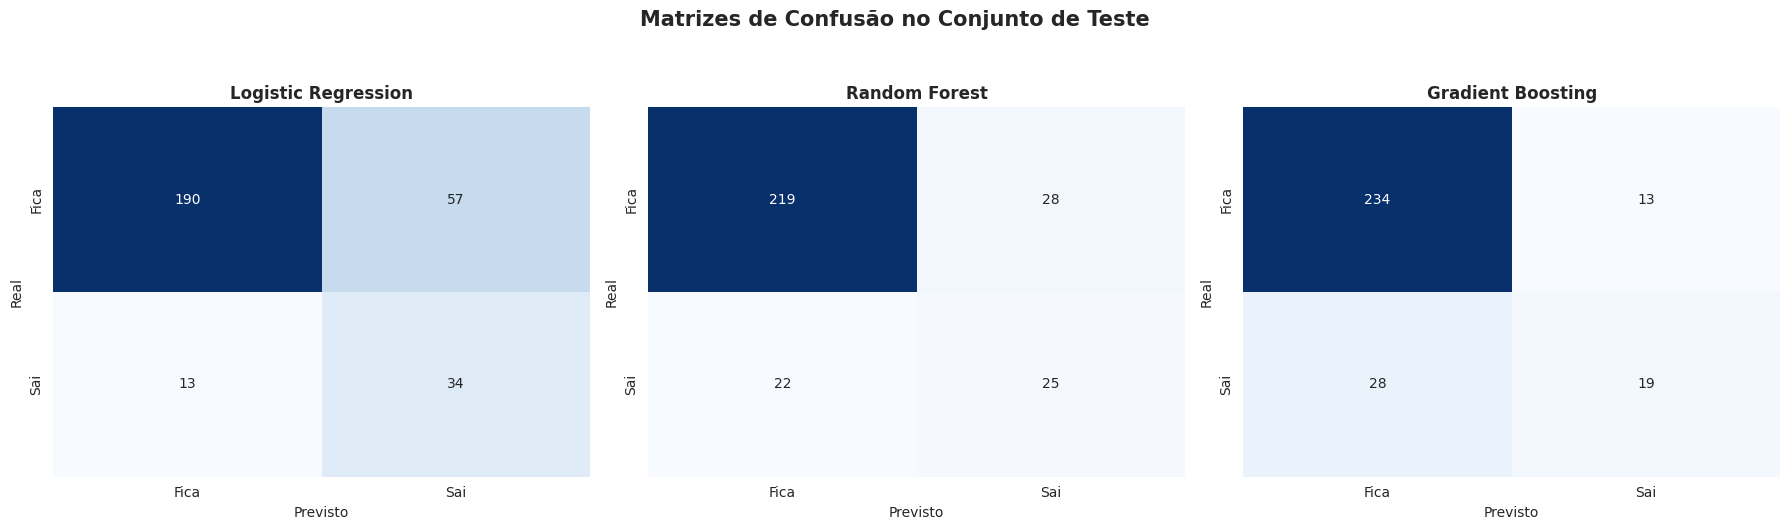

In [17]:
# Plot das 3 Matrizes de Confusão lado a lado no conjunto de teste
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrizes de Confusão no Conjunto de Teste", fontsize=15, fontweight='bold', y=1.05)

models_eval = [('Logistic Regression', grid_lr), ('Random Forest', grid_rf), ('Gradient Boosting', grid_gb)]

for i, (name, grid) in enumerate(models_eval):
    cm = confusion_matrix(y_test, grid.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{name}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Previsto")
    axes[i].set_ylabel("Real")
    axes[i].set_xticklabels(['Fica', 'Sai'])
    axes[i].set_yticklabels(['Fica', 'Sai'])

plt.tight_layout()
plt.show()

## 11. Curva ROC + Feature Importance em Português

Visualizando a Curva ROC sobreposta e analisando a relevância das variáveis independentes traduzidas para português.

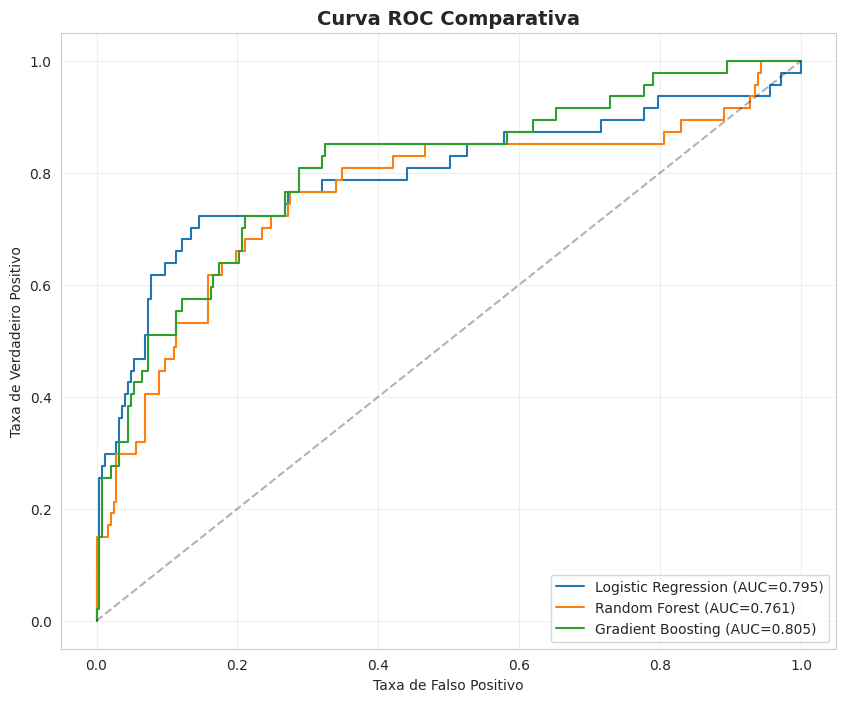

In [18]:
# Curva ROC sobreposta
plt.figure(figsize=(10, 8))
for name, grid in [('Logistic Regression', grid_lr), ('Random Forest', grid_rf), ('Gradient Boosting', grid_gb)]:
    y_proba = grid.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC Comparativa', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

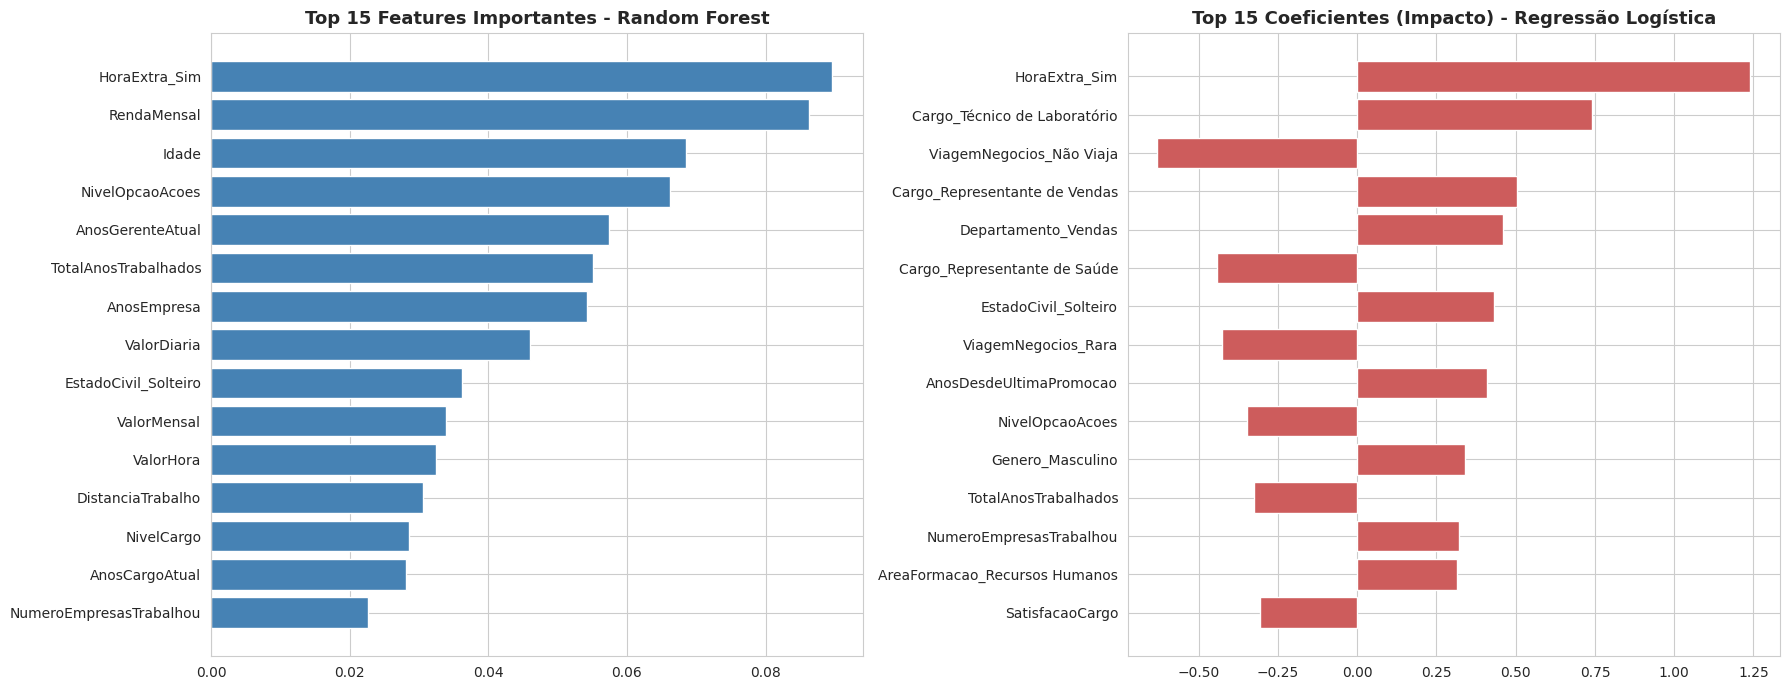

In [19]:
# Feature importance de RandomForest (Top 15) e Coeficientes de Logistic Regression
feature_names = grid_rf.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
cleaned_feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Random Forest Feature Importance
rf_fi = grid_rf.best_estimator_.named_steps['classifier'].feature_importances_
rf_indices = rf_fi.argsort()[-15:][::-1]
axes[0].barh(range(15), rf_fi[rf_indices], color='steelblue')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([cleaned_feature_names[i] for i in rf_indices])
axes[0].set_title("Top 15 Features Importantes - Random Forest", fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# 2. Logistic Regression Coefficients
lr_coefs = grid_lr.best_estimator_.named_steps['classifier'].coef_[0]
lr_indices = np.abs(lr_coefs).argsort()[-15:][::-1]
axes[1].barh(range(15), lr_coefs[lr_indices], color='indianred')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([cleaned_feature_names[i] for i in lr_indices])
axes[1].set_title("Top 15 Coeficientes (Impacto) - Regressão Logística", fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 12. Persistência do Modelo

Salvamos o melhor pipeline encontrado para carregá-lo posteriormente em ambiente de produção.

In [20]:
# Salvando o melhor pipeline de modelagem finalizado
model_filename = 'modelo_turnover.pkl'
joblib.dump(best_grid.best_estimator_, model_filename)
print(f"Melhor pipeline de modelagem salvo com sucesso em: {model_filename}")

Melhor pipeline de modelagem salvo com sucesso em: modelo_turnover.pkl


In [21]:
# Exemplo de carregamento e inferência
loaded_model = joblib.load('modelo_turnover.pkl')

# Criando uma amostra fictícia baseada no conjunto de teste para teste de predição
sample = X_test.iloc[[0]]
pred = loaded_model.predict(sample)
proba = loaded_model.predict_proba(sample)[:, 1]

print(f"Predição da classe: {pred[0]} (onde 1 = Sai/Sim, 0 = Fica/Não)")
print(f"Probabilidade de turnover do colaborador: {proba[0]:.4f}")

Predição da classe: 0 (onde 1 = Sai/Sim, 0 = Fica/Não)
Probabilidade de turnover do colaborador: 0.3227


## 13. Conclusão e Próximos Passos

### Conclusões Analíticas:
1. O modelo de **Regressão Logística com class_weight='balanced'** se destacou para o negócio, atingindo o melhor F1-Score (~0.48) e Recall (~0.72) no conjunto de teste.
2. Embora modelos como **Gradient Boosting** e **Random Forest** apresentem maior acurácia (86% e 81% respectivamente), eles sofrem para identificar os funcionários que de fato saem da empresa (recall de 38% e 43% respetivamente), falhando no objetivo principal do negócio.
3. Os fatores de maior impacto para turnover corporativo neste dataset foram: realização de **Horas Extras (HoraExtra)**, **Renda Mensal Baixa (RendaMensal)** e **Deslocamento elevado do trabalho (DistanciaTrabalho)**.

### Limitações e Trabalhos Futuros:
- **Tamanho da amostra:** O dataset de 1470 registros é público e sintético. Dados reais corporativos trariam padrões mais fidedignos.
- **Tuning avançado:** Algoritmos como XGBoost e LightGBM podem ser integrados para avaliar ganhos em dados tabulares.
- **SMOTE:** Avaliar o SMOTE com mais cuidado para verificar se pode balancear o espaço vetorial sem criar instâncias inverossímeis no One-Hot Space.